In [4]:
import pandas
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt
import os
import sys
from reproject import reproject_interp

# We will reproject the JWST dust mask to the HST image

In [6]:
# load the hst mosaic image
hst_mosaic = fits.open("/Users/mncavieres/Documents/2026-1/Sombrero_REVEAL/Data/HST/MAST_2026-03-10T1856/HST/u2j20e07t/u2j20e07t_drw.fits")

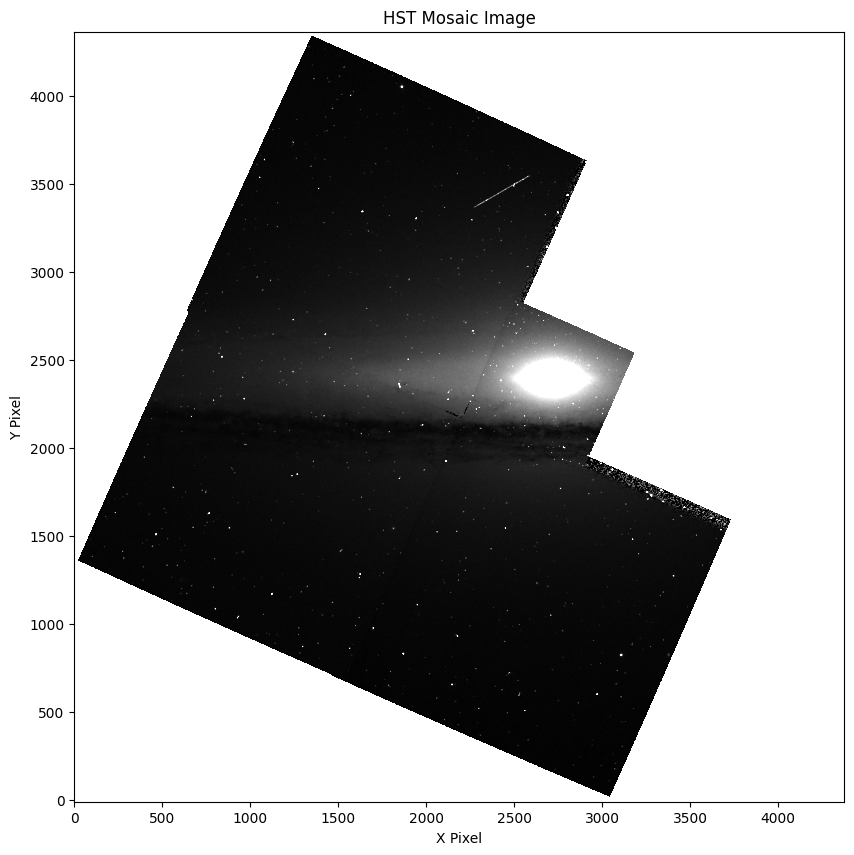

In [21]:
# view the hst mosaic image
fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(hst_mosaic[1].data, origin="lower", cmap="gray",
          vmin=np.nanpercentile(hst_mosaic[1].data, 1),
          vmax=np.nanpercentile(hst_mosaic[1].data, 99))
ax.set_title("HST Mosaic Image")
ax.set_xlabel("X Pixel")
ax.set_ylabel("Y Pixel")
ax.set_box_aspect(1)
plt.show()

In [3]:
# read the JWST dust mask
jwst_dust_mask = fits.open("/Users/mncavieres/Documents/2026-1/Sombrero_REVEAL/Data/dust_mask/f200_mask_1.fits")

# Reproject the dustmask to the HST frame and shape

In [8]:
hst_dust_mask = reproject_interp(jwst_dust_mask, shape_out=hst_mosaic[1].data.shape, output_projection=hst_mosaic[1].header)

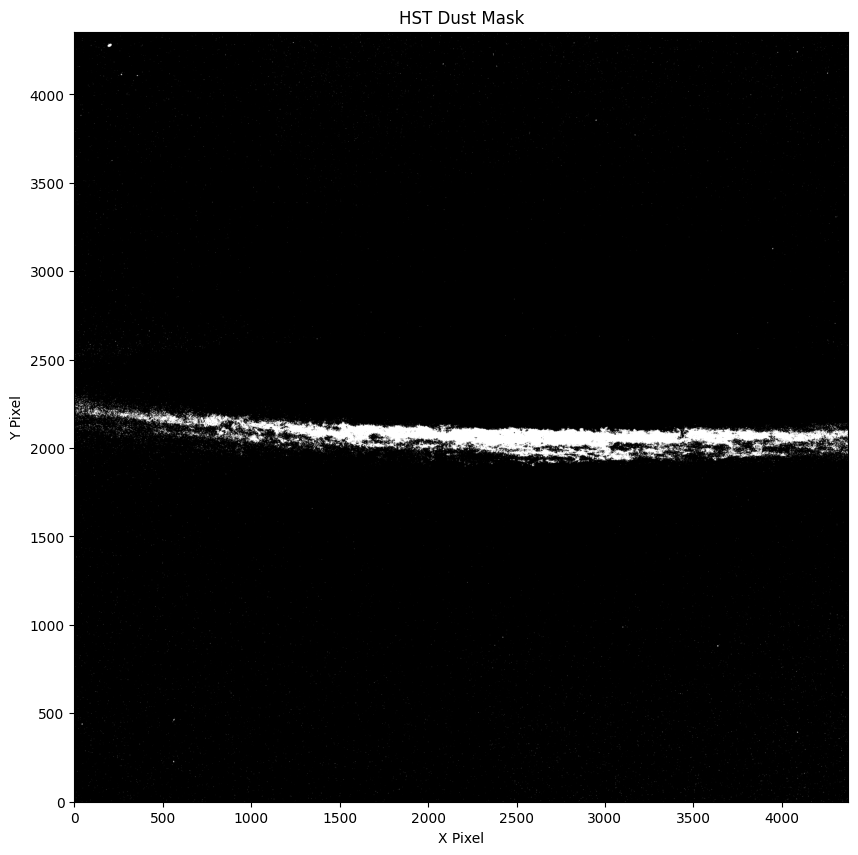

In [10]:
# view the hst dust mask
hst_dust_mask_image, hst_dust_mask_footprint = hst_dust_mask

fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(hst_dust_mask_image, origin="lower", cmap="gray")
ax.set_title("HST Dust Mask")
ax.set_xlabel("X Pixel")
ax.set_ylabel("Y Pixel")
plt.show()

In [11]:
# save the hst dust mask as a fits file
hdu = fits.PrimaryHDU(hst_dust_mask_image, header=hst_mosaic[1].header)
hdu.writeto("/Users/mncavieres/Documents/2026-1/Sombrero_REVEAL/Data/dust_mask/hst_dust_mask_f814w.fits", overwrite=True)

In [16]:
# make sure that the mask is binary (0 for dust, 1 for no dust)
hst_dust_mask_binary = np.where(hst_dust_mask_image > 0, 0, 1)
# now it is boolean, we should make it binary (0 and 1)
hst_dust_mask_binary = hst_dust_mask_binary.astype(int)

In [19]:
# save the hst dust mask as a fits file
hdu = fits.PrimaryHDU(hst_dust_mask_binary, header=hst_mosaic[1].header)
hdu.writeto("/Users/mncavieres/Documents/2026-1/Sombrero_REVEAL/Data/dust_mask/hst_dust_mask_f814w.fits", overwrite=True)

array([[False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       ...,
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False]])